In [83]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res, read_ripser_result
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print
from utils.pd_utils import sort_cycle
from utils.confidence_utils import median_max_life_time, get_bottleneck_dist

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA

from persim import plot_diagrams
from utils.pd_utils import get_life_times
import pandas as pd

env: CUDA_VISIBLE_DEVICES=1
[KeOps] Warning : cuda was detected, but driver API could not be initialized. Switching to cpu only.


In [84]:
root_path = get_path("data")
fig_path = get_path("figures")
# seeds = [0, 1, 2]
seeds = [0]
k = 15

style_file = "utils.style"
plt.style.use(style_file)

distances = {
    "euclidean": [{}],
        "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    ],
}

# embedding+mask loading if procrustes

In [ ]:
embd_tasic_orange = np.load(os.path.join(root_path, "embd_after_procrustes", "embd_tasic_orange.npy"))


# embedding loading and mask making if not procrustes

In [34]:
n_epochs = 500
n_early_epochs = 250
perplexity = None    
rescale_tsne = True
seed = 0
file_name = os.path.join(root_path,
                         "tasic",
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_{seed}_init_pca_rescale_{rescale_tsne}.pkl")
tsne_data = load_dict(file_name)
embd = tsne_data["embds"][-1]

In [91]:
_, _, _, _, full_d = load_dataset(root_path, "tasic", k=k)

In [93]:
mask_Pvalb = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Pvalb")
mask_Sst = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Sst")
mask_orange = np.maximum(mask_Pvalb, mask_Sst)

In [8]:
print("dataset size of orange is ", sum(mask_orange))

dataset size of orange is  5113


# load data!


In [ ]:
dataset = "tasic_orange"
x, y, sknn, pca2, d = load_dataset(root_path, dataset, k=k, seed=0)
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)

Done with tasic_orange None euclidean n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


# most persistent!

## shuffle_pts

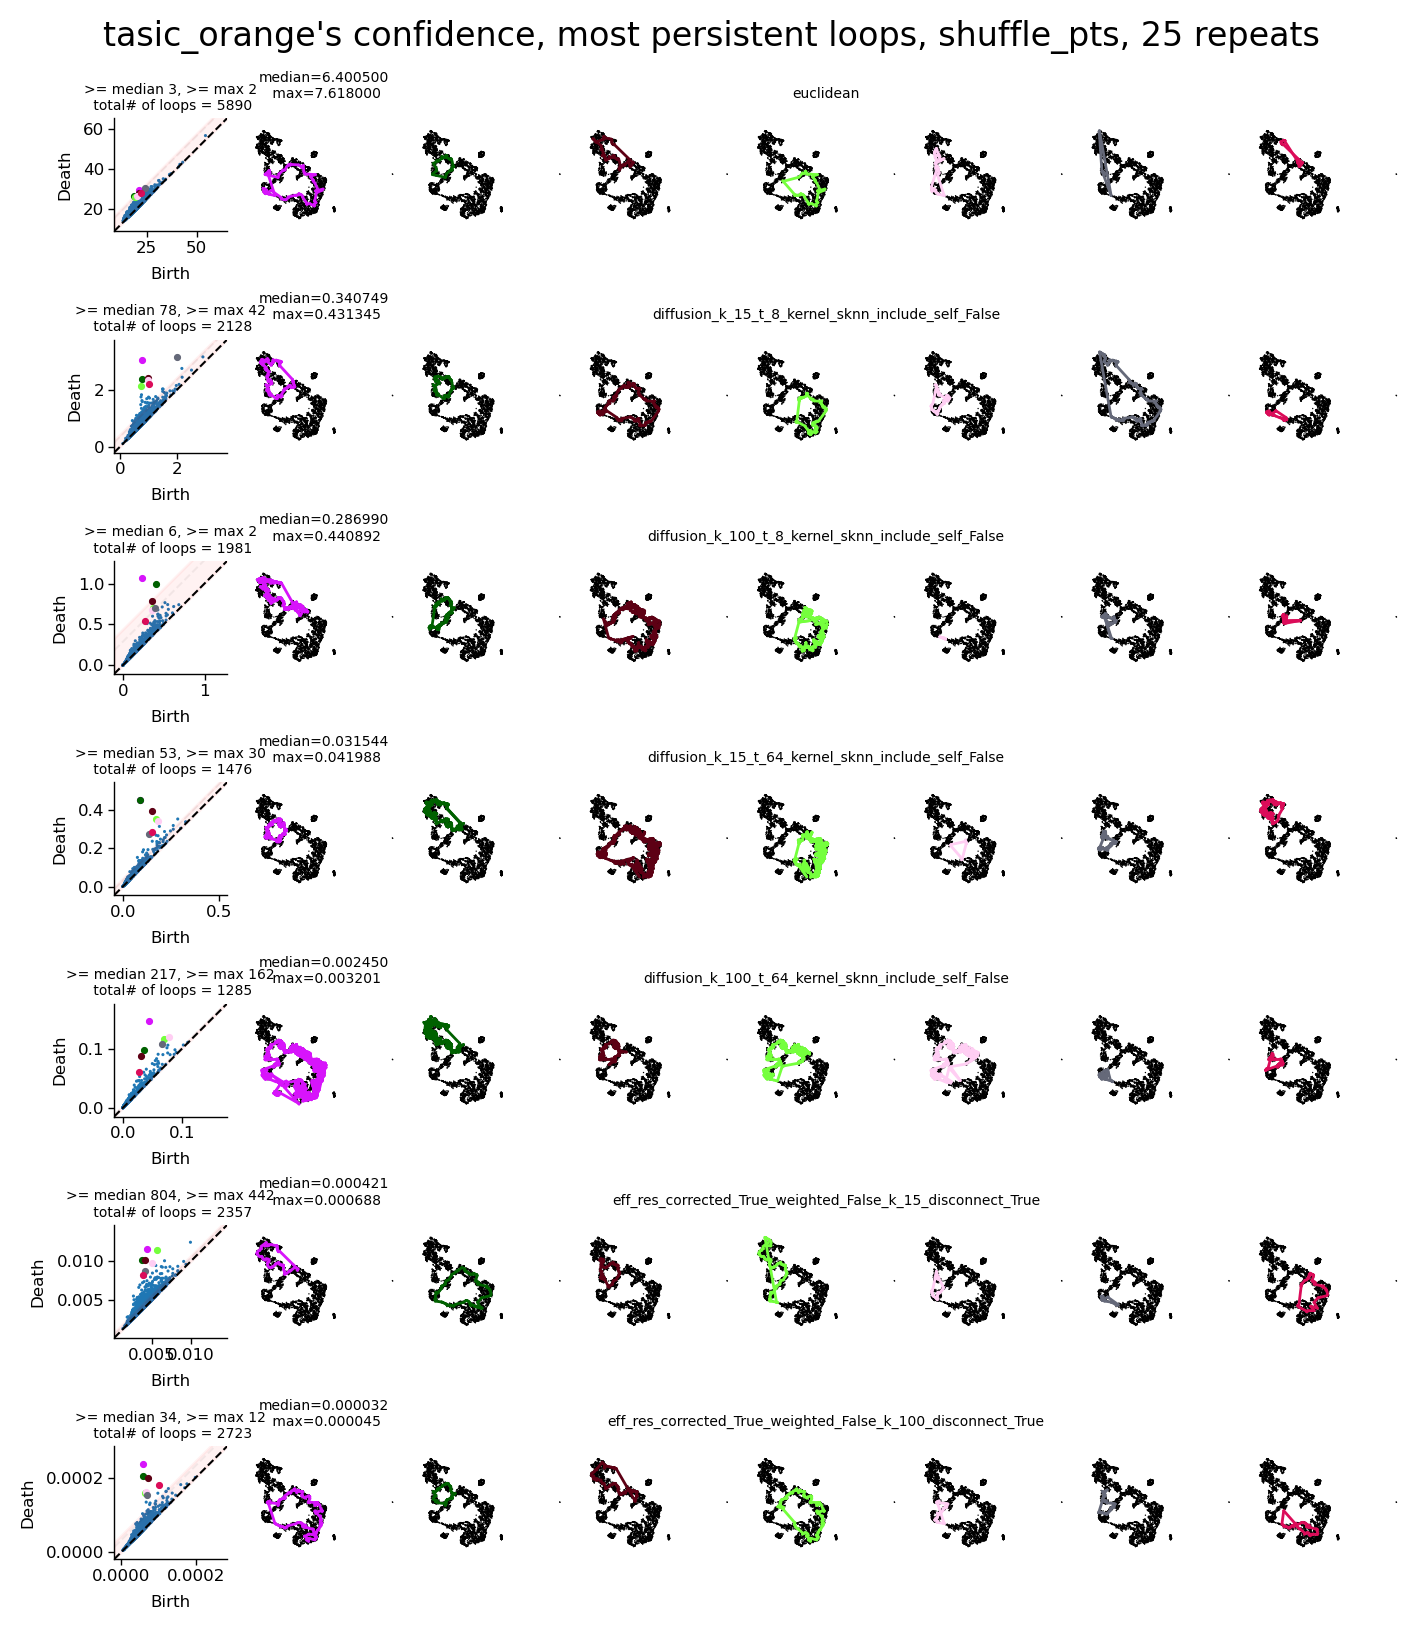

In [ ]:
fig_most_persistent(all_res,  dataset=dataset, embd_n_mask =  embd_tasic_orange , method="shuffle_pts", save = True)

## bootstrap

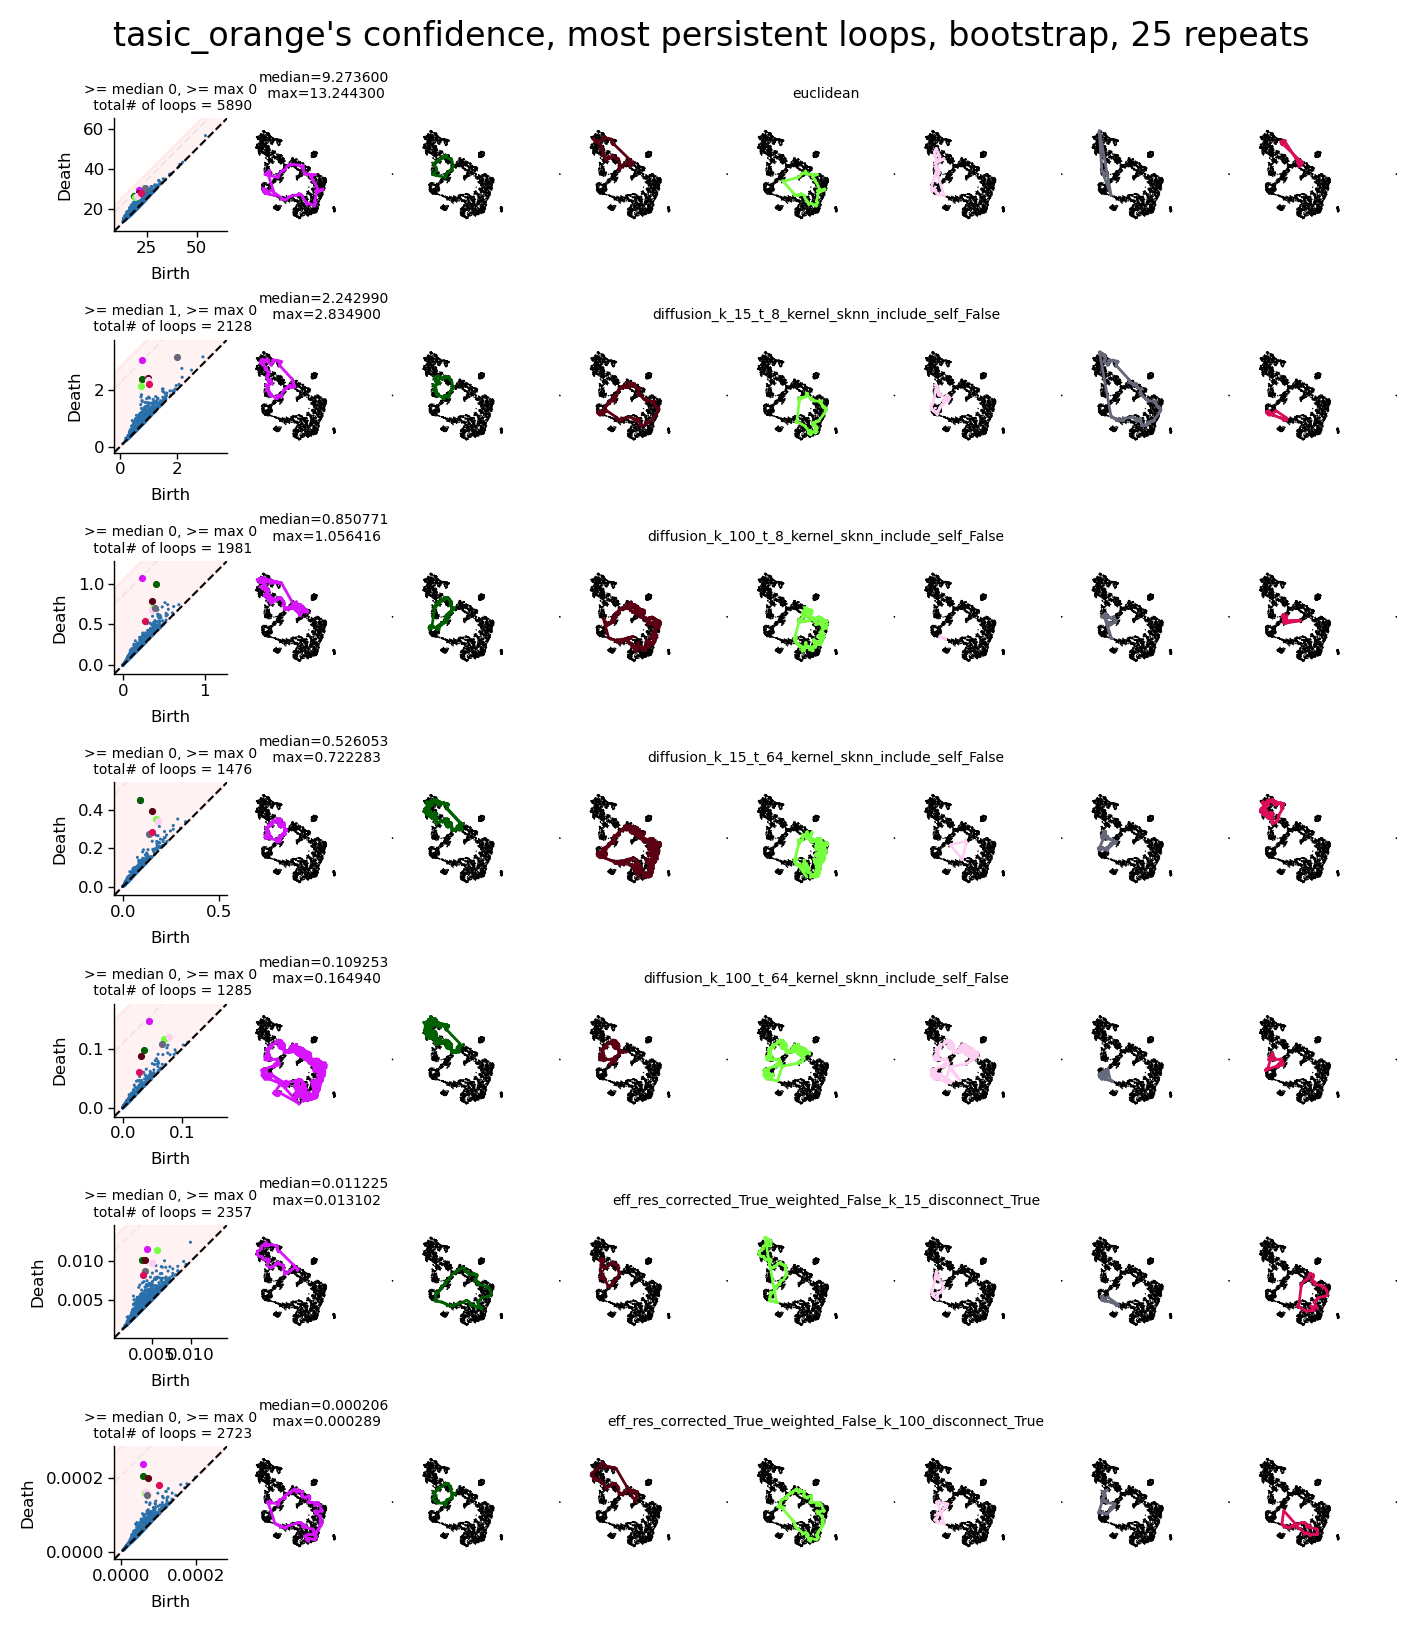

In [ ]:
fig_most_persistent(all_res,  dataset=dataset, embd_n_mask =  embd_tasic_orange , method="bootstrap", save = True)

# check the distribution and number of detected loops in original and shuffled/bootstrapped data

## birth time 

327548
97789
80068
31015
27556
3347
6975


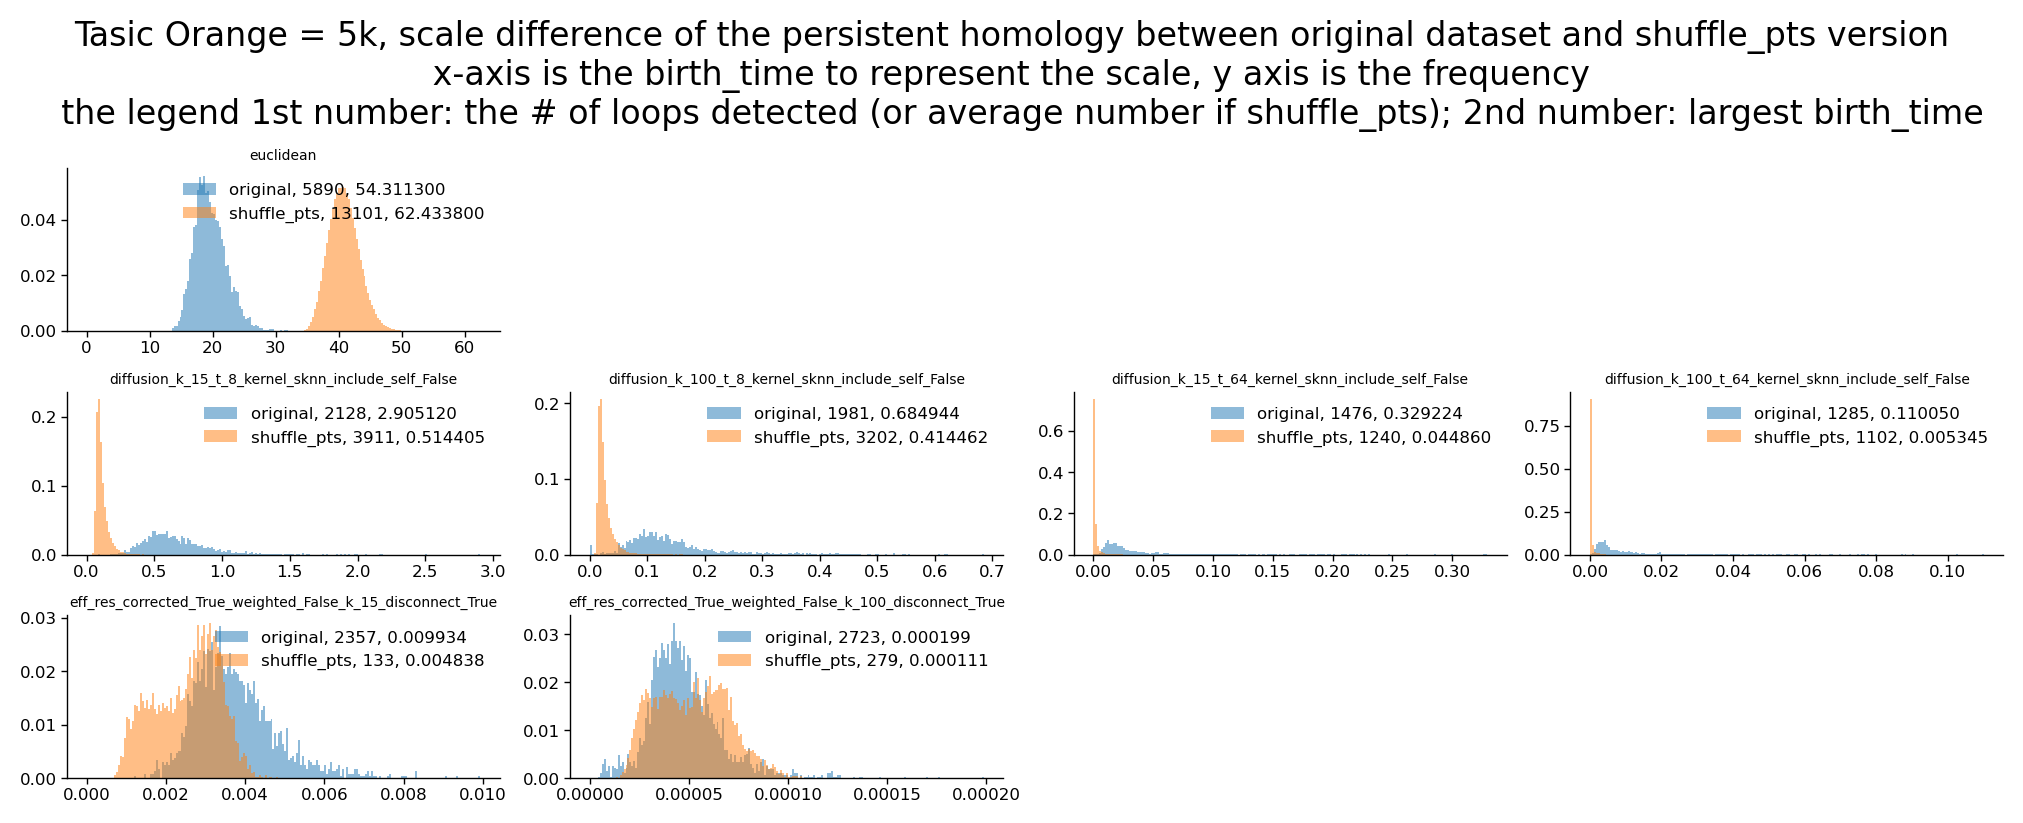

In [ ]:
# method = "bootstrap"
method = "shuffle_pts"
condition = "birth_time"

fig, ax = plt.subplots(3,4, figsize=(10, 4))
seed = 0
for i, distance in enumerate(distances.keys()):
    n_plots = len(all_res[distance].keys())
    if n_plots<4:
        for j in range(n_plots, 4):
            ax[i][j].axis("off")
    for j, full_dist in enumerate(all_res[distance]):
        life_array = all_res[distance][full_dist]["dgms"][1]
        reference_life_long = life_array[:,0]
        num = len(life_array)
        life_longs = []
        for r in range(25):
            file_name = os.path.join(root_path,
                                dataset,
                                f"{dataset}_seed_{seed}_{method}_{r}_{full_dist}_rep")
            life_array = read_ripser_result(file_name)["dgms"][1]
            life_long = life_array[:,0]
            life_longs.extend(life_long)
        num_25 = int(np.floor(len(life_longs)/25))
        list_bin = np.max([np.max(reference_life_long), np.max(life_longs)])
        longest_original = np.max(reference_life_long)
        longest_method = np.max(life_longs)
        ax[i][j].hist(reference_life_long, bins=np.linspace(0, list_bin, 200), weights=np.ones_like(reference_life_long)/len(reference_life_long),alpha = 0.5, label = f"original, {num}, " + "{:3f}".format(longest_original) )
        ax[i][j].hist(life_longs, bins=np.linspace(0, list_bin, 200), weights=np.ones_like(life_longs)/len(life_longs),alpha = 0.5,label = f"{method}, {num_25}, " + "{:3f}".format(longest_method))
        ax[i][j].set_title(f"{full_dist}",  fontsize = 5)
        print(len(life_longs))
        
        ax[i][j].legend(loc="upper right", frameon=False)


fig.suptitle(f"Tasic Orange = 5k, scale difference of the persistent homology between original dataset and {method} version\n x-axis is the {condition} to represent the scale, y axis is the frequency \n  the legend 1st number: the # of loops detected (or average number if {method}); 2nd number: largest {condition}", fontsize = 12)       
plt.show()
fig.savefig(os.path.join(get_path("figures"), f"scale_frequency_{condition}_{method}.png"), dpi=300)


83894
30516
29269
22752
19449
34227
39514


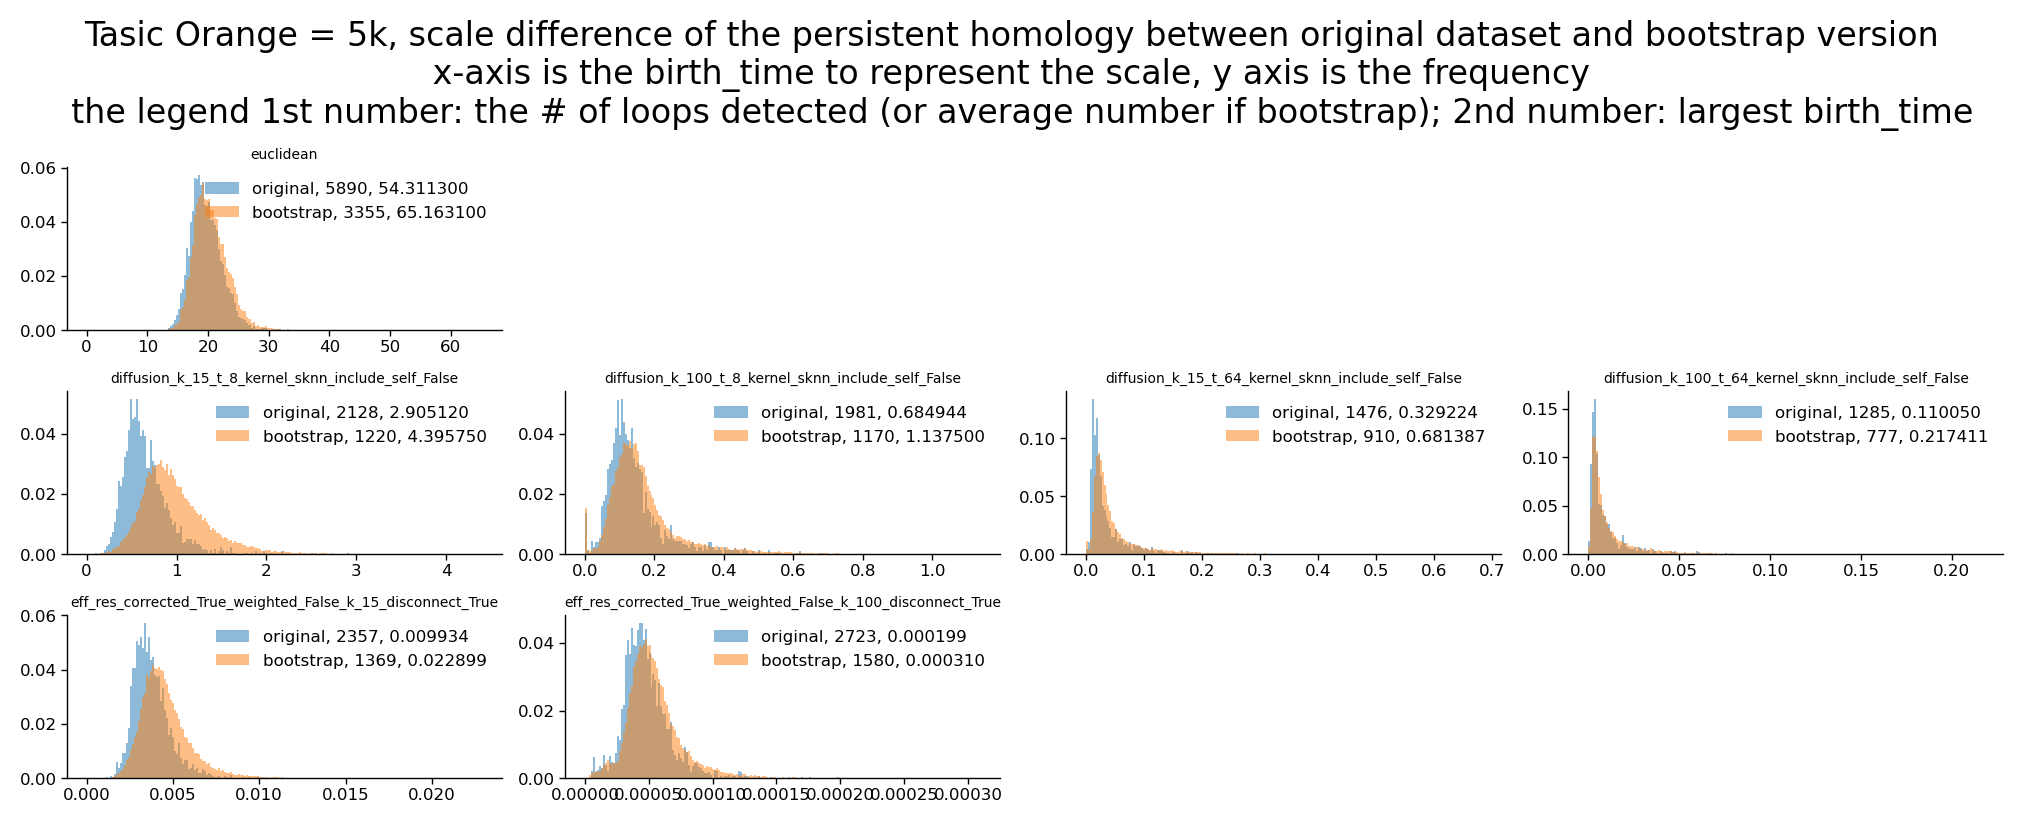

In [ ]:
method = "bootstrap"
# method = "shuffle_pts"
condition = "birth_time"
fig, ax = plt.subplots(3,4, figsize=(10, 4))
seed = 0
for i, distance in enumerate(distances.keys()):
    n_plots = len(all_res[distance].keys())
    if n_plots<4:
        for j in range(n_plots, 4):
            ax[i][j].axis("off")
    for j, full_dist in enumerate(all_res[distance]):
        life_array = all_res[distance][full_dist]["dgms"][1]
        reference_life_long = life_array[:,0]
        num = len(life_array)

        life_longs = []
        for r in range(25):
            file_name = os.path.join(root_path,
                                dataset,
                                f"{dataset}_seed_{seed}_{method}_{r}_{full_dist}_rep")
            life_array = read_ripser_result(file_name)["dgms"][1]
            life_long = life_array[:,0]
            life_longs.extend(life_long)
        
        num_25 = int(np.floor(len(life_longs)/25))
        list_bin = np.max([np.max(reference_life_long), np.max(life_longs)])
        longest_original = np.max(reference_life_long)
        longest_method = np.max(life_longs)
        ax[i][j].hist(reference_life_long, bins=np.linspace(0, list_bin, 200), weights=np.ones_like(reference_life_long)/len(reference_life_long),alpha = 0.5, label = f"original, {num}, " + "{:3f}".format(longest_original) )
        ax[i][j].hist(life_longs, bins=np.linspace(0, list_bin, 200), weights=np.ones_like(life_longs)/len(life_longs),alpha = 0.5,label = f"{method}, {num_25}, " + "{:3f}".format(longest_method))
        ax[i][j].set_title(f"{full_dist}",  fontsize = 5)
        
        print(len(life_longs))
        
        ax[i][j].legend(loc="upper right", frameon=False)
fig.suptitle(f"Tasic Orange = 5k, scale difference of the persistent homology between original dataset and {method} version\n x-axis is the {condition} to represent the scale, y axis is the frequency \n  the legend 1st number: the # of loops detected (or average number if {method}); 2nd number: largest {condition}", fontsize = 12)       
plt.show()
fig.savefig(os.path.join(get_path("figures"), f"scale_frequency_{condition}_{method}.png"), dpi=300)


## life long

327548
97789
80068
31015
27556
3347
6975


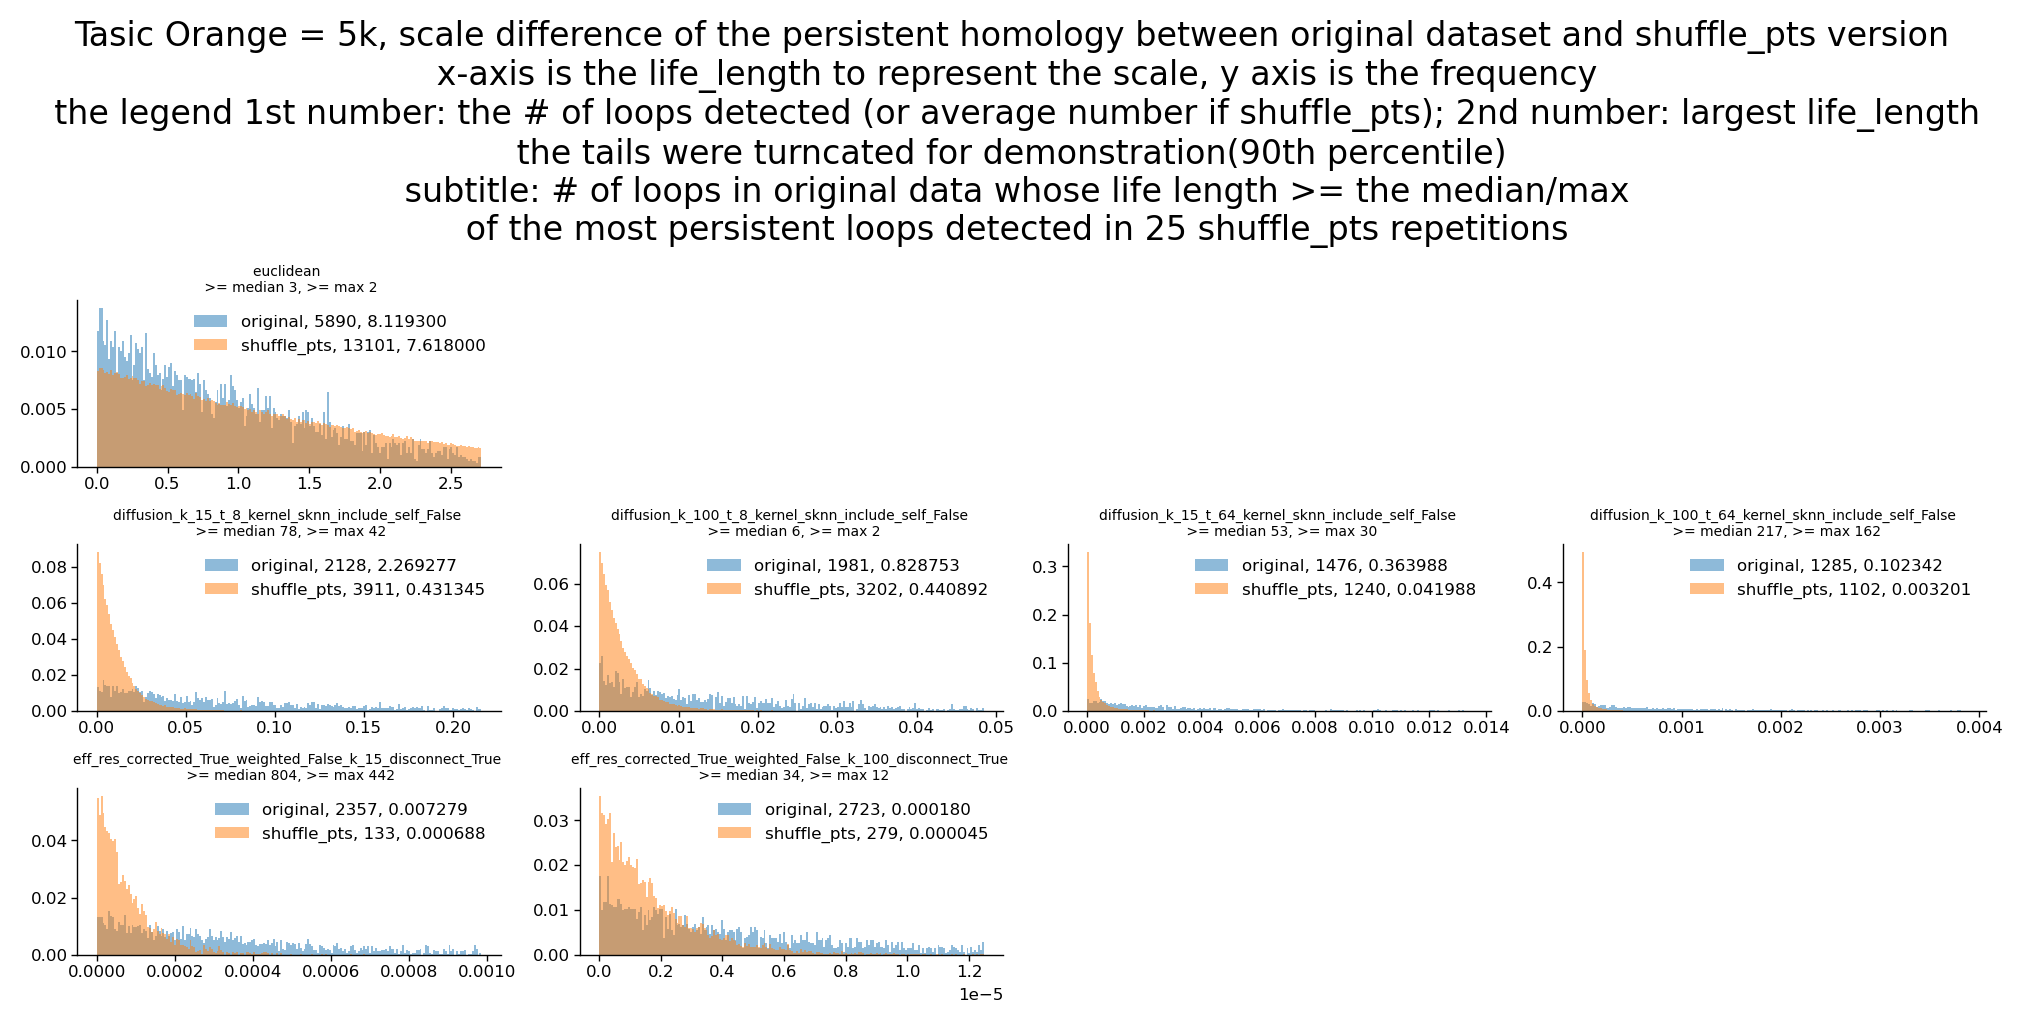

In [ ]:
# method = "bootstrap"
method = "shuffle_pts"
condition = "life_length"

fig, ax = plt.subplots(3,4, figsize=(10, 5))
seed = 0
for i, distance in enumerate(distances.keys()):
    n_plots = len(all_res[distance].keys())
    if n_plots<4:
        for j in range(n_plots, 4):
            ax[i][j].axis("off")
    for j, full_dist in enumerate(all_res[distance]):
        life_array = all_res[distance][full_dist]["dgms"][1]
        reference_life_long = life_array[:,1] - life_array[:,0]
        
        num = len(life_array)
        life_longs = []
        max_lengths = []
        for r in range(25):
            file_name = os.path.join(root_path,
                                dataset,
                                f"{dataset}_seed_{seed}_{method}_{r}_{full_dist}_rep")
            life_array = read_ripser_result(file_name)["dgms"][1]
            life_long = life_array[:,1] - life_array[:,0]
            life_longs.extend(life_long)
            max_lengths.append(np.max(life_long))
        num_25 = int(np.floor(len(life_longs)/25))
        median_length = np.median(max_lengths)
        max_length = np.max(max_lengths)
        
        geq_median = np.sum(np.array(reference_life_long) >= median_length)
        geq_max = np.sum(np.array(reference_life_long) >= max_length)
        
        longest_original = np.max(reference_life_long)
        longest_method = np.max(life_longs)
        list_bin = np.max([np.percentile(reference_life_long, 90), np.percentile(life_longs, 90)])
        ax[i][j].hist(reference_life_long, bins=np.linspace(0, list_bin, 200), weights=np.ones_like(reference_life_long)/len(reference_life_long),alpha = 0.5, label = f"original, {num}, " + "{:3f}".format(longest_original) )
        ax[i][j].hist(life_longs, bins=np.linspace(0, list_bin, 200), weights=np.ones_like(life_longs)/len(life_longs),alpha = 0.5,label = f"{method}, {num_25}, " + "{:3f}".format(longest_method))
                # life_longs = [i for i in life_longs]
        ax[i][j].set_title(f"{full_dist} \n >= median {geq_median}, >= max {geq_max}",  fontsize = 5)
        print(len(life_longs))
        
        ax[i][j].legend(loc="upper right", frameon=False)


fig.suptitle(f"Tasic Orange = 5k, scale difference of the persistent homology between original dataset and {method} version"
             + f"\n x-axis is the {condition} to represent the scale, y axis is the frequency"
             + f"\n  the legend 1st number: the # of loops detected (or average number if {method}); 2nd number: largest {condition} "
             + f"\n the tails were turncated for demonstration(90th percentile) "
             + f"\n subtitle: # of loops in original data whose life length >= the median/max"
             + f"\n of the most persistent loops detected in 25 {method} repetitions", fontsize = 12)       
plt.show()
fig.savefig(os.path.join(get_path("figures"), f"scale_frequency_{condition}_{method}.png"), dpi=300)


83894
30516
29269
22752
19449
34227
39514


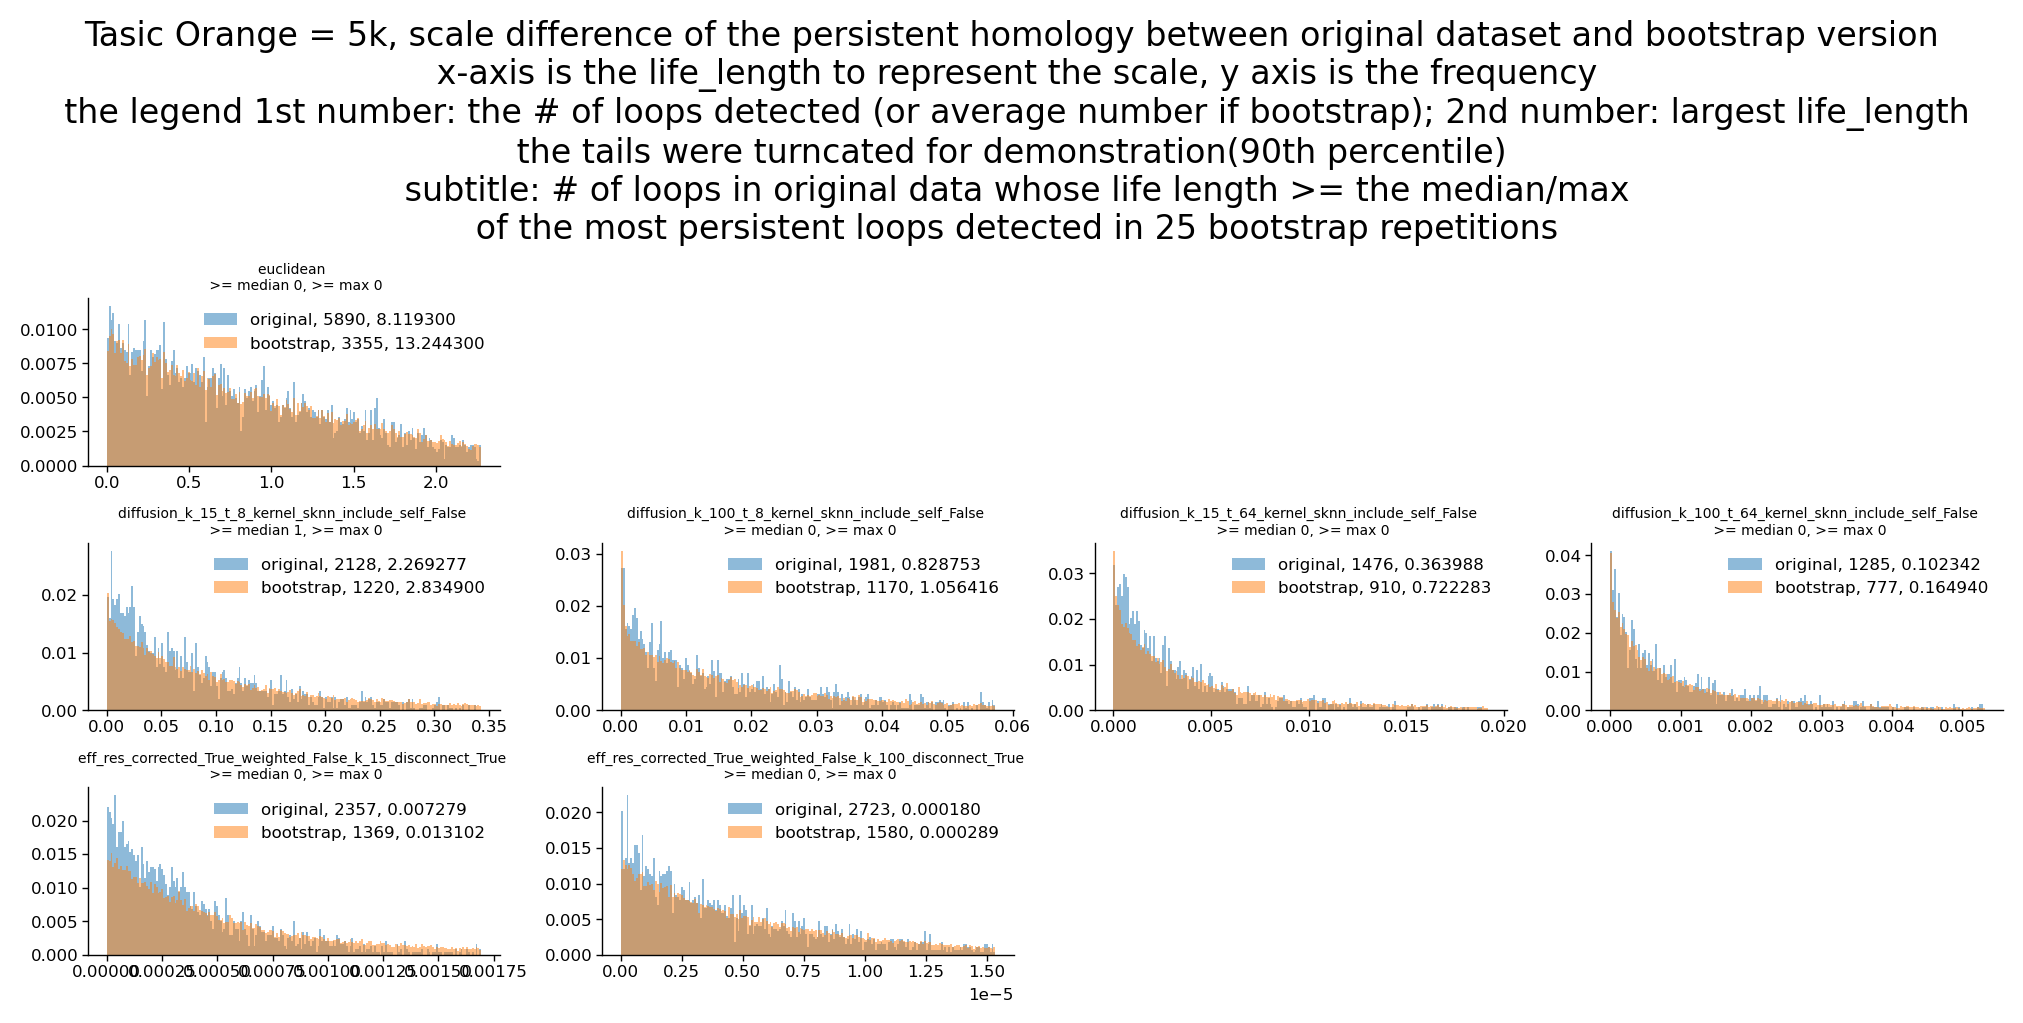

In [ ]:
method = "bootstrap"
# method = "shuffle_pts"
condition = "life_length"

fig, ax = plt.subplots(3,4, figsize=(10, 5))
seed = 0
for i, distance in enumerate(distances.keys()):
    n_plots = len(all_res[distance].keys())
    if n_plots<4:
        for j in range(n_plots, 4):
            ax[i][j].axis("off")
    for j, full_dist in enumerate(all_res[distance]):
        life_array = all_res[distance][full_dist]["dgms"][1]
        reference_life_long = life_array[:,1] - life_array[:,0]
        
        num = len(life_array)
        life_longs = []
        max_lengths = []
        for r in range(25):
            file_name = os.path.join(root_path,
                                dataset,
                                f"{dataset}_seed_{seed}_{method}_{r}_{full_dist}_rep")
            life_array = read_ripser_result(file_name)["dgms"][1]
            life_long = life_array[:,1] - life_array[:,0]
            life_longs.extend(life_long)
            max_lengths.append(np.max(life_long))
        num_25 = int(np.floor(len(life_longs)/25))
        median_length = np.median(max_lengths)
        max_length = np.max(max_lengths)
        
        geq_median = np.sum(np.array(reference_life_long) >= median_length)
        geq_max = np.sum(np.array(reference_life_long) >= max_length)
        
        longest_original = np.max(reference_life_long)
        longest_method = np.max(life_longs)
        list_bin = np.max([np.percentile(reference_life_long, 90), np.percentile(life_longs, 90)])
        ax[i][j].hist(reference_life_long, bins=np.linspace(0, list_bin, 200), weights=np.ones_like(reference_life_long)/len(reference_life_long),alpha = 0.5, label = f"original, {num}, " + "{:3f}".format(longest_original) )
        ax[i][j].hist(life_longs, bins=np.linspace(0, list_bin, 200), weights=np.ones_like(life_longs)/len(life_longs),alpha = 0.5,label = f"{method}, {num_25}, " + "{:3f}".format(longest_method))
                # life_longs = [i for i in life_longs]
        ax[i][j].set_title(f"{full_dist} \n >= median {geq_median}, >= max {geq_max}",  fontsize = 5)
        print(len(life_longs))
        
        ax[i][j].legend(loc="upper right", frameon=False)


fig.suptitle(f"Tasic Orange = 5k, scale difference of the persistent homology between original dataset and {method} version"
             + f"\n x-axis is the {condition} to represent the scale, y axis is the frequency"
             + f"\n  the legend 1st number: the # of loops detected (or average number if {method}); 2nd number: largest {condition} "
             + f"\n the tails were turncated for demonstration(90th percentile) "
             + f"\n subtitle: # of loops in original data whose life length >= the median/max"
             + f"\n of the most persistent loops detected in 25 {method} repetitions", fontsize = 12)       
plt.show()
fig.savefig(os.path.join(get_path("figures"), f"scale_frequency_{condition}_{method}.png"), dpi=300)
